<a href="https://colab.research.google.com/github/moeinHP-aussie/image-processing/blob/main/DIP_Ex6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="direction: rtl; line-height: 300%;">
  <font face="XB Zar" size="5">
    <div align="center">
      <font face="IranNastaliq" size="30">
        <p></p>
      </font>
    </div>
    <br>
    <div align="center">
      <font color="brown" size="6">
        معین حسن پور - 40032313
      </font>
    </div>
    <br>
    <div align="center">
      <font color="navy">
        <b><u>تمرین ششم</u> پردازش تصاویر رنگی</b>
      

  </font>
</div>
  </font>
</div>
<hr>

<div dir="rtl">
<h2>یک تصویر رنگی با حداقل ۱۰۰۰۰ رنگ  در نظر گیرید و تعداد رنگ های آن را به ۲۵۶ کاهش دهید بگونه ای که به کیفیت رنگی تصویر خرابی چندانی وارد نشود. کدام مد نمایش رنگ به بهترین شکل میتواند به شما کمک کند؟
</div>

<div dir="rtl">
  <font color="green">
        <h2>استفاده از HSV آسیب کمتری به رنگ ها وارد میکند زیرا میتوان  بخش saturation و value را ثابت نگه داشت و فقط hue ها رو به 256 دسته کاهش داد که به این صورت روشنایی و غلظ رنگ تصویر تغییر نمیکند.<br> و همچنین از حجم محاسبات کم میشود.
        <br><br>همچنین در برنامه زیر برای کم کردن تعداد رنگ ها بصورت موثر، از خوشه بندی hue ها استفاده شده
  </font>
</div>


In [9]:
from PIL import Image
import numpy as np
import cv2  # برای تبدیل به فضای HSV

# calculate color variety of picture
image = Image.open("download (2).jpg")  # مسیر تصویر رو وارد کن

img_hsv = cv2.cvtColor( image , cv2.COLOR_RGB2HSV)

pixels = np.array(image)

pixels = pixels.reshape(-1, 3)

unique_colors = np.unique(pixels, axis=0)

print(f'Number of unique colors in {str(image)} :', len(unique_colors))


Number of unique colors in <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=736x1308 at 0x7857C29AAB10> : 343352


In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

img_np = np.array(image)
w, h = image.size

hue_values = img_hsv[:, :, 0].reshape(-1, 1)  #جدا کردن hue از دو فاکتور دیگر

# KMeans بر روی Hue
kmeans = KMeans(n_clusters=256, random_state=0).fit(hue_values)  # خوشه‌بندی فقط بر روی Hue
new_hues = kmeans.cluster_centers_.astype('uint8')
labels = kmeans.labels_

# خوشه‌بندی رنگ‌ها
quantized_hue = new_hues[labels].reshape(img_hsv[:, :, 0].shape)

quantized_img_hsv = img_hsv.copy()
quantized_img_hsv[:, :, 0] = quantized_hue  # فقط کانال Hue را تغییر می‌دهیم

# تبدیل تصویر نهایی به RGB
quantized_img_rgb = cv2.cvtColor(quantized_img_hsv, cv2.COLOR_HSV2RGB)


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (179) found smaller than n_clusters (256). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [17]:
# ذخیره تصویر جدید
Image.fromarray(quantized_img_rgb).save("quantized_image_hue_only.jpg")


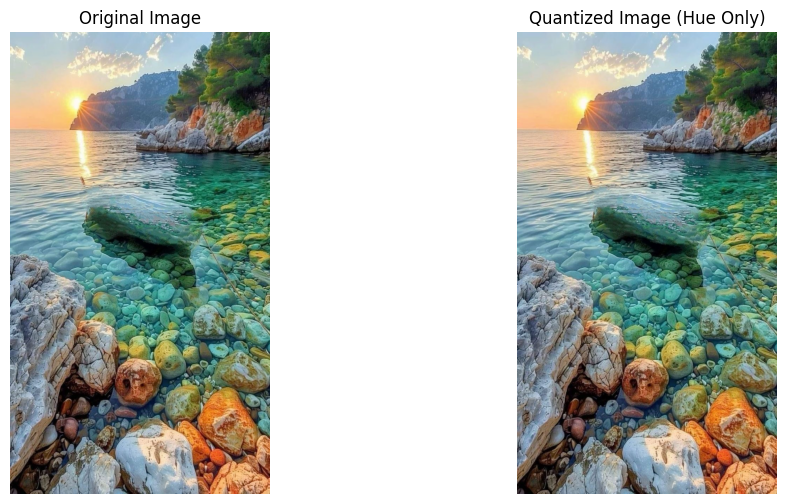

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# نمایش تصویر قدیمی
axes[0].imshow(img_np)
axes[0].set_title("Original Image")
axes[0].axis('off')

# نمایش تصویر جدید
axes[1].imshow(quantized_img_rgb)
axes[1].set_title("Quantized Image (Hue Only)")
axes[1].axis('off')

plt.show()

<div dir="rtl">
  <font color="green">
        <h2>شایان ذکر است که حجم عکس نهایی فقط کمی کاهش پیدا کرده. اگر هدف کاهش دادن حجم عکس باشد rgb بهتر است.